C:\Users\asdxo\AppData\Local\Temp\ipykernel_2096\3548965867.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Correlation_with_Stage2', y='Signal', data=corr_df.sort_values('Correlation_with_Stage2', ascending=False), palette='coolwarm')


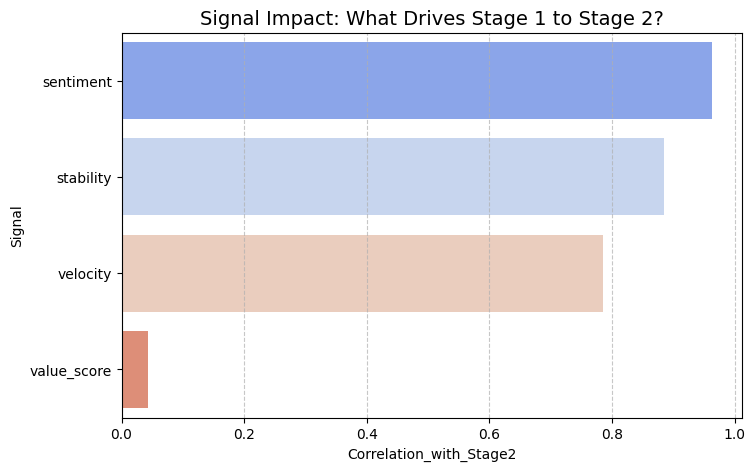

### [Step 1] Kruskal-Wallis Test: Stage 1 vs Stage 2 Difference
     Signal  H-Statistic      p-value
   velocity  8797.891015 0.000000e+00
  sentiment 10533.361816 0.000000e+00
value_score    27.992866 1.217635e-07
  stability  9308.570322 0.000000e+00

### [Step 2] Correlation with 'Graduating' to Stage 2
     Signal  Correlation_with_Stage2  p-value
   velocity                 0.785140 0.000000
  sentiment                 0.963235 0.000000
value_score                 0.043315 0.000002
  stability                 0.884458 0.000000


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, pearsonr

base_path = '../../../../data/preprocessed/'
df_graded = pd.read_csv(f'{base_path}steam_indie_games_graded.csv')
df_silence = pd.read_csv(f'{base_path}steam_indie_games_silence.csv')
hist_df = pd.read_csv(f'{base_path}steam_indie_review_histogram.csv')

df = pd.concat([df_graded, df_silence], ignore_index=True)
df = df[df['total_reviews'] > 0].copy()

def assign_stage(rev_count):
    if 1 <= rev_count <= 9: return 1
    elif 10 <= rev_count <= 49: return 2
    elif 50 <= rev_count <= 499: return 3
    else: return 4

df['stage'] = df['total_reviews'].apply(assign_stage)

hist_df['daily_pos_rate'] = (hist_df['recommendations_up'] / 
                            (hist_df['recommendations_up'] + hist_df['recommendations_down'] + 1e-6)) * 100
stability_stats = hist_df.groupby('appid')['daily_pos_rate'].std().reset_index(name='stability')

df = pd.merge(df, stability_stats, on='appid', how='left')
df['velocity'] = df['total_reviews']
df['sentiment'] = df['positive_rate']
df['value_score'] = df['recommendations_total'].fillna(0) / (df['owners_lower'] + 1)

features = ['velocity', 'sentiment', 'value_score', 'stability']
df[features] = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)

analysis_df = df[df['stage'].isin([1, 2])].copy()

kw_results = []
for f in features:
    groups = [analysis_df[analysis_df['stage'] == s][f] for s in [1, 2]]
    stat, p = kruskal(*groups)
    kw_results.append({'Signal': f, 'H-Statistic': stat, 'p-value': p})
kw_df = pd.DataFrame(kw_results)

corr_list = []
analysis_df['is_stage_up'] = (analysis_df['stage'] == 2).astype(int)
for f in features:
    r, p = pearsonr(analysis_df[f], analysis_df['is_stage_up'])
    corr_list.append({'Signal': f, 'Correlation_with_Stage2': r, 'p-value': p})

corr_df = pd.DataFrame(corr_list)

plt.figure(figsize=(8, 5))
sns.barplot(x='Correlation_with_Stage2', y='Signal', data=corr_df.sort_values('Correlation_with_Stage2', ascending=False), palette='coolwarm')
plt.title('Signal Impact: What Drives Stage 1 to Stage 2?', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("### [Step 1] Kruskal-Wallis Test: Stage 1 vs Stage 2 Difference")
print(kw_df.to_string(index=False))
print("\n" + "="*80)
print("### [Step 2] Correlation with 'Graduating' to Stage 2")
print(corr_df.to_string(index=False))